# `anndataoom` API reference — a 10k-cell walkthrough

Every public method of `AnnDataOOM` demonstrated on a 10,016-cell dataset from CellxGene. The matrix never leaves disk — each operation streams through chunks as needed.

**Dataset**: HTAPP-944-SMP-7479 scRNA-seq (10,016 cells × 25,146 genes, 96 MB on disk)

**What's covered**

| Section | Topic | Methods |
|---|---|---|
| 1 | Reading & display | `oom.read()`, `_repr_html_` |
| 2 | Dimensions & keys | `.shape`, `.n_obs`, `.n_vars`, `.obs_keys()`, `.var_keys()`, `.obsm_keys()`, `.uns_keys()` |
| 3 | obs / var / obsm | `.obs`, `.var`, `.obsm`, `.obs_names`, `.var_names`, `.filename` |
| 4 | Subsetting | `adata[...]`, `_inplace_subset_obs/var`, `subset()` |
| 5 | Data access | `.to_df()`, `.obs_vector()`, `.var_vector()`, `.chunk_X()`, `.chunked_X()` |
| 6 | Raw | `.raw`, `raw.obs_vector()` |
| 7 | Layers | `.layers[key]` |
| 8 | Name utilities | `.obs_names_make_unique()`, `.strings_to_categoricals()` |
| 9 | Copy / Transpose / Memory | `.copy()`, `.T`, `.to_adata()`, `.to_memory()` |
| 10 | Writing | `.write()`, `.write_h5ad()` |
| 11 | Visualisation (omicverse) | `ov.pl.embedding`, `ov.pl.dotplot`, `ov.pl.violin` |
| 12 | Cleanup | `.close()` |

## 1. Reading

`oom.read(path)` opens an h5ad file out-of-memory. The source file is opened read-only by default.

In [1]:
import anndataoom as oom
from pathlib import Path

DATA_PATH = Path("./data/htapp_10k.h5ad")
if not DATA_PATH.exists():
    import urllib.request
    DATA_PATH.parent.mkdir(exist_ok=True)
    url = "https://datasets.cellxgene.cziscience.com/9c37f134-4481-46ac-a22f-ef844ed0259a.h5ad"
    print(f"Downloading {url} ...")
    urllib.request.urlretrieve(url, DATA_PATH)
    print(f"Saved to {DATA_PATH} ({DATA_PATH.stat().st_size / 1024**2:.1f} MB)")

In [2]:
adata = oom.read(DATA_PATH)
print(adata)

╭────────────────────────────────────────────────────────────────────────╮
│ AnnDataOOM                               Rust · out-of-memory · backed │
├────────────────────────────────────────────────────────────────────────┤
│                                                                        │
│    10,016   ×   25,146                                                 │
│    obs           vars                                                  │
│                                                                        │
│    csr_matrix · float32 · 16.9% density · ~32.5 MB/chunk (1,000 rows)  │
│    htapp_10k.h5ad                                                      │
│                                                                        │
├────────────────────────────────────────────────────────────────────────┤
│ ▸ obs    (34)   replicate · condition · labels_unif  +31               │
│ ▸ var    (18)   n_cells · mt · n_cells_by_counts · mean_counts  +14    │
│ ▸ obsm   (2)    X_pca ·

In [3]:
adata

name,dtype,preview
replicate,category,"1, 2"
condition,category,TST
labels_unif,category,"Epithelial, Neurons, Endothelial, … (29)"
labels_cl_unif,category,"Epithelial, Mesangial cells, Endothelial, … (8)"
labels_cl_unif2_broad,category,"Epithelial_neuro, Endothelial, Smooth muscle, … (7)"
compartments,category,"Malignant, Stromal, Myeloid, … (4)"
cnv_pass_mal,category,"True, False"
Phase,category,"G1, G2M, S"
n_genes_by_counts,int32,"5110, 6072, 7505, … (4140)"
total_counts,float32,"10332.0, 9930.0, 19942.0, … (5330)"


The cell output above is rendered by `_repr_html_()` — each section is clickable to expand (in Jupyter). The plain-text `repr()` is also available, and used automatically in terminals.

## 2. Dimensions and key listings

In [4]:
adata.shape

(10016, 25146)

In [5]:
adata.n_obs, adata.n_vars

(10016, 25146)

In [6]:
adata.obs_keys()

['replicate',
 'condition',
 'labels_unif',
 'labels_cl_unif',
 'labels_cl_unif2_broad',
 'compartments',
 'cnv_pass_mal',
 'Phase',
 'n_genes_by_counts',
 'total_counts',
 'pct_counts_mt',
 'n_counts',
 'n_genes',
 'total_counts_mt',
 'leiden',
 'is_primary_data',
 'development_stage_ontology_term_id',
 'disease_ontology_term_id',
 'self_reported_ethnicity_ontology_term_id',
 'sex_ontology_term_id',
 'tissue_ontology_term_id',
 'suspension_type',
 'cell_type_ontology_term_id',
 'donor_id',
 'tissue_type',
 'assay_ontology_term_id',
 'cell_type',
 'assay',
 'disease',
 'sex',
 'tissue',
 'self_reported_ethnicity',
 'development_stage',
 'observation_joinid']

In [7]:
adata.var_keys()

['n_cells',
 'mt',
 'n_cells_by_counts',
 'mean_counts',
 'pct_dropout_by_counts',
 'total_counts',
 'highly_variable',
 'highly_variable_rank',
 'means',
 'variances',
 'variances_norm',
 'highly_variable_nbatches',
 'feature_is_filtered',
 'feature_name',
 'feature_reference',
 'feature_biotype',
 'feature_length',
 'feature_type']

In [8]:
adata.obsm_keys(), adata.varm_keys(), adata.uns_keys()

(['X_pca', 'X_umap'],
 [],
 ['default_embedding',
  'leiden',
  'organism_ontology_term_id',
  'counts_var',
  'schema_reference',
  'pca',
  'neighbors',
  'schema_version',
  'title',
  'umap',
  'hvg',
  'organism',
  'cell_type_ontology_term_id_colors',
  'citation'])

In [9]:
adata.is_view, adata.isbacked

(False, True)

In [10]:
adata.filename

PosixPath('data/htapp_10k.h5ad')

## 3. `obs`, `var`, `obsm`

`obs` and `var` are standard pandas `DataFrame` objects — string columns are automatically stored as `category` dtype to save memory.

In [11]:
adata.obs.head()

,replicate,condition,labels_unif,labels_cl_unif,labels_cl_unif2_broad,compartments,cnv_pass_mal,Phase,n_genes_by_counts,total_counts,...,tissue_type,assay_ontology_term_id,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
obs_names,,,,,,,,,,,,,,,,,,,,,
HTAPP-944-SMP-7479-TST-channel1_CACAACACATCGTTCC-1,1,TST,Epithelial,Epithelial,Epithelial_neuro,Malignant,True,G1,5110,10332.0,...,tissue,EFO:0009922,malignant cell,10x 3' v3,breast cancer,female,liver,unknown,46-year-old stage,@60N2&n{|#
HTAPP-944-SMP-7479-TST-channel1_TAACTTCAGCAACTCT-1,1,TST,Neurons,Mesangial cells,Epithelial_neuro,Malignant,True,G2M,6072,9930.0,...,tissue,EFO:0009922,malignant cell,10x 3' v3,breast cancer,female,liver,unknown,46-year-old stage,SK498wkiE8
HTAPP-944-SMP-7479-TST-channel1_ACCTACCGTTCCTAAG-1,1,TST,Epithelial,Epithelial,Epithelial_neuro,Malignant,True,S,7505,19942.0,...,tissue,EFO:0009922,malignant cell,10x 3' v3,breast cancer,female,liver,unknown,46-year-old stage,REuXqL8coO
HTAPP-944-SMP-7479-TST-channel1_AACGAAAGTCTCTCCA-1,1,TST,Epithelial,Epithelial,Epithelial_neuro,Malignant,True,G1,7615,19949.0,...,tissue,EFO:0009922,malignant cell,10x 3' v3,breast cancer,female,liver,unknown,46-year-old stage,JP$p}wXdg0
HTAPP-944-SMP-7479-TST-channel1_CATGCCTAGAGCCCAA-1,1,TST,Neurons,Mesangial cells,Epithelial_neuro,Malignant,True,S,7898,19524.0,...,tissue,EFO:0009922,malignant cell,10x 3' v3,breast cancer,female,liver,unknown,46-year-old stage,(%_Ei`Qd4u


In [12]:
adata.obs.dtypes

replicate                                   category
condition                                   category
labels_unif                                 category
labels_cl_unif                              category
labels_cl_unif2_broad                       category
compartments                                category
cnv_pass_mal                                category
Phase                                       category
n_genes_by_counts                              int32
total_counts                                 float32
pct_counts_mt                                float32
n_counts                                     float32
n_genes                                        int64
total_counts_mt                              float32
leiden                                      category
is_primary_data                                 bool
development_stage_ontology_term_id          category
disease_ontology_term_id                    category
self_reported_ethnicity_ontology_term_id    ca

In [13]:
adata.obs["labels_cl_unif2_broad"].value_counts()

labels_cl_unif2_broad
Endothelial         4226
Epithelial_neuro    3833
Smooth muscle       1014
Macrophage           409
Monocyte             351
NK                   179
Fibroblast             4
Name: count, dtype: int64

In [14]:
adata.var.head()

,n_cells,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
var_names,,,,,,,,,,,,,,,,,,
ENSG00000241599,3,False,3,0.000300,99.970048,3.0,False,NaN,0.000300,0.000299,0.494071,0,False,ENSG00000241599,NCBITaxon:9606,gene,457,lncRNA
ENSG00000235146,22,False,22,0.002196,99.780351,22.0,False,NaN,0.002196,0.002192,0.985054,0,False,ENSG00000235146,NCBITaxon:9606,gene,675,lncRNA
ENSG00000237491,2147,False,2147,0.214956,78.564297,2153.0,False,NaN,0.214956,0.169965,0.907099,0,False,LINC01409,NCBITaxon:9606,gene,1089,lncRNA
ENSG00000177757,15,False,15,0.001498,99.850240,15.0,False,NaN,0.001498,0.001496,0.986669,0,False,FAM87B,NCBITaxon:9606,gene,1960,lncRNA
ENSG00000225880,114,False,114,0.011382,98.861821,114.0,False,NaN,0.011382,0.011253,0.980417,0,False,LINC00115,NCBITaxon:9606,gene,874,lncRNA


In [15]:
adata.obs_names[:5]

Index(['HTAPP-944-SMP-7479-TST-channel1_CACAACACATCGTTCC-1',
       'HTAPP-944-SMP-7479-TST-channel1_TAACTTCAGCAACTCT-1',
       'HTAPP-944-SMP-7479-TST-channel1_ACCTACCGTTCCTAAG-1',
       'HTAPP-944-SMP-7479-TST-channel1_AACGAAAGTCTCTCCA-1',
       'HTAPP-944-SMP-7479-TST-channel1_CATGCCTAGAGCCCAA-1'],
      dtype='object', name='obs_names')

In [16]:
adata.var_names[:5]

Index(['ENSG00000241599', 'ENSG00000235146', 'ENSG00000237491',
       'ENSG00000177757', 'ENSG00000225880'],
      dtype='object', name='var_names')

In [17]:
adata.obsm["X_umap"].shape, adata.obsm["X_pca"].shape

((10016, 2), (10016, 50))

## 4. Subsetting

All indexing styles return a new `AnnDataOOM` that shares the backing file — no data is copied.

In [18]:
# Integer slice — rows
adata[0:1000]

name,dtype,preview
replicate,category,1
condition,category,TST
labels_unif,category,"Epithelial, Neurons, Endothelial, … (12)"
labels_cl_unif,category,"Epithelial, Mesangial cells, Endothelial, … (7)"
labels_cl_unif2_broad,category,"Epithelial_neuro, Endothelial, Smooth muscle, … (5)"
compartments,category,"Malignant, Stromal, Myeloid"
cnv_pass_mal,category,"True, False"
Phase,category,"G1, G2M, S"
n_genes_by_counts,int32,"5110, 6072, 7505, … (862)"
total_counts,float32,"10332.0, 9930.0, 19942.0, … (912)"


In [19]:
# Integer slice — both axes
adata[0:100, 0:500]

name,dtype,preview
replicate,category,1
condition,category,TST
labels_unif,category,"Epithelial, Neurons, Endothelial, … (5)"
labels_cl_unif,category,"Epithelial, Mesangial cells, Endothelial, … (4)"
labels_cl_unif2_broad,category,"Epithelial_neuro, Endothelial"
compartments,category,"Malignant, Stromal"
cnv_pass_mal,category,"True, False"
Phase,category,"G1, G2M, S"
n_genes_by_counts,int32,"5110, 6072, 7505, … (96)"
total_counts,float32,"10332.0, 9930.0, 19942.0, … (100)"


In [20]:
# Boolean mask
adata[adata.obs["labels_cl_unif2_broad"] == "Endothelial"]

name,dtype,preview
replicate,category,"1, 2"
condition,category,TST
labels_unif,category,"Endothelial, Smooth muscle, Chondrocyte, … (4)"
labels_cl_unif,category,Endothelial
labels_cl_unif2_broad,category,Endothelial
compartments,category,Stromal
cnv_pass_mal,category,"False, True"
Phase,category,"G1, S, G2M"
n_genes_by_counts,int32,"7698, 7898, 7791, … (2267)"
total_counts,float32,"19210.0, 16393.0, 15924.0, … (2790)"


In [21]:
# Single gene by name
adata[:, "ENSG00000198804"]

name,dtype,preview
replicate,category,"1, 2"
condition,category,TST
labels_unif,category,"Epithelial, Neurons, Endothelial, … (29)"
labels_cl_unif,category,"Epithelial, Mesangial cells, Endothelial, … (8)"
labels_cl_unif2_broad,category,"Epithelial_neuro, Endothelial, Smooth muscle, … (7)"
compartments,category,"Malignant, Stromal, Myeloid, … (4)"
cnv_pass_mal,category,"True, False"
Phase,category,"G1, G2M, S"
n_genes_by_counts,int32,"5110, 6072, 7505, … (4140)"
total_counts,float32,"10332.0, 9930.0, 19942.0, … (5330)"


In [22]:
# List of gene names
adata[:, list(adata.var_names[:10])]

name,dtype,preview
replicate,category,"1, 2"
condition,category,TST
labels_unif,category,"Epithelial, Neurons, Endothelial, … (29)"
labels_cl_unif,category,"Epithelial, Mesangial cells, Endothelial, … (8)"
labels_cl_unif2_broad,category,"Epithelial_neuro, Endothelial, Smooth muscle, … (7)"
compartments,category,"Malignant, Stromal, Myeloid, … (4)"
cnv_pass_mal,category,"True, False"
Phase,category,"G1, G2M, S"
n_genes_by_counts,int32,"5110, 6072, 7505, … (4140)"
total_counts,float32,"10332.0, 9930.0, 19942.0, … (5330)"


### In-place subsetting

`_inplace_subset_obs` / `_inplace_subset_var` modify the current object. `subset()` is the anndata-rs–style alias.

In [23]:
# Demonstrate on a copy so we don't affect the original object
c = adata.copy()
c._inplace_subset_obs(c.obs["labels_cl_unif2_broad"].values == "Endothelial")
c

[AnnDataOOM] copy(): shallow copy — obs/var/obsm are independent copies, X still reads from the same backing file (no memory cost).
  Use adata.copy(to_memory=True) or adata.to_adata() to materialise into RAM.


name,dtype,preview
replicate,category,"1, 2"
condition,category,TST
labels_unif,category,"Endothelial, Smooth muscle, Chondrocyte, … (4)"
labels_cl_unif,category,Endothelial
labels_cl_unif2_broad,category,Endothelial
compartments,category,Stromal
cnv_pass_mal,category,"False, True"
Phase,category,"G1, S, G2M"
n_genes_by_counts,int32,"7698, 7898, 7791, … (2267)"
total_counts,float32,"19210.0, 16393.0, 15924.0, … (2790)"


## 5. Data access

### `to_df()` — small DataFrame views

In [24]:
# Materialise a small window into a pandas DataFrame
adata[:5, :8].to_df()

var_names,ENSG00000241599,ENSG00000235146,ENSG00000237491,ENSG00000177757,ENSG00000225880,ENSG00000230368,ENSG00000272438,ENSG00000223764
obs_names,,,,,,,,
HTAPP-944-SMP-7479-TST-channel1_CACAACACATCGTTCC-1,0.0,0.0,0.676950,0.0,0.0,0.0,0.0,0.0
HTAPP-944-SMP-7479-TST-channel1_TAACTTCAGCAACTCT-1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
HTAPP-944-SMP-7479-TST-channel1_ACCTACCGTTCCTAAG-1,0.0,0.0,0.406434,0.0,0.0,0.0,0.0,0.0
HTAPP-944-SMP-7479-TST-channel1_AACGAAAGTCTCTCCA-1,0.0,0.0,0.694425,0.0,0.0,0.0,0.0,0.0
HTAPP-944-SMP-7479-TST-channel1_CATGCCTAGAGCCCAA-1,0.0,0.0,0.413559,0.0,0.0,0.0,0.0,0.0


### `obs_vector(gene)` — per-gene expression vector

Streams through chunks and builds just the target column. RAM bounded by one chunk.

In [25]:
# Pick a gene from feature_name (symbol) → Ensembl ID
gene_symbol = "EPCAM"
ensembl_id = adata.var.index[adata.var["feature_name"] == gene_symbol][0]
expr = adata.obs_vector(ensembl_id)
expr.shape, expr.dtype, expr.min(), expr.max()

((10016,), dtype('float32'), np.float32(0.0), np.float32(3.4857092))

### `var_vector(obs_name)` — per-cell expression across all genes

Mirror of `obs_vector`: fetches a single cell's values across all genes.

In [26]:
cell_id = adata.obs_names[0]
cell_expr = adata.var_vector(cell_id)
cell_expr.shape, cell_expr.dtype

((25146,), dtype('float32'))

### `chunk_X(n)` — random sample of `n` rows

In [27]:
random_chunk = adata.chunk_X(500)
random_chunk.shape, type(random_chunk).__name__

((500, 25146), 'csr_matrix')

### `chunked_X(chunk_size)` — sequential row-chunk iterator

The core lazy primitive. Yields `(start, end, chunk)` where `chunk` is a sparse/dense matrix for rows `[start, end)`.

In [28]:
for start, end, chunk in adata.chunked_X(2000):
    print(f"rows [{start:>5}:{end:<5}]  type={type(chunk).__name__}  shape={chunk.shape}")

rows [    0:2000 ]  type=csr_matrix  shape=(2000, 25146)
rows [ 2000:4000 ]  type=csr_matrix  shape=(2000, 25146)
rows [ 4000:6000 ]  type=csr_matrix  shape=(2000, 25146)


rows [ 6000:8000 ]  type=csr_matrix  shape=(2000, 25146)
rows [ 8000:10000]  type=csr_matrix  shape=(2000, 25146)
rows [10000:10016]  type=csr_matrix  shape=(16, 25146)


### Chunked aggregates on `.X`

`BackedArray` exposes `.sum()`, `.mean()`, `.var()`, `.getnnz()` — all implemented as single-pass chunked computations.

In [29]:
adata.X.sum(axis=1)   # per-cell total counts

array([4293.42382812, 5108.39990234, 4524.32177734, ..., 1048.07165527,
       1013.46472168, 1030.94458008], shape=(10016,))

In [30]:
adata.X.getnnz(axis=0)   # per-gene nonzero count (how many cells express each gene)

array([   3,   22, 2147, ...,  290,    6,   93], shape=(25146,))

## 6. `raw`

`adata.raw` is a lightweight snapshot — typically used before HVG subsetting so you can access all genes after filtering.

In [31]:
# Demonstrate: set raw, subset to 500 genes, then access all genes via raw
adata.raw = adata
adata_hvg = adata[:, adata.var_names[:500]]
adata_hvg.shape, adata_hvg.raw.shape

((10016, 500), (10016, 25146))

In [32]:
# A gene not in the subset but present in raw
gene_outside = str(adata.var_names[10_000])
adata_hvg.raw.obs_vector(gene_outside).shape

(10016,)

## 7. `layers`

`layers` is a dict-like container aligned to `(n_obs, n_vars)`. When you assign a `BackedArray`, it's stored as a lazy reference (zero memory).

In [33]:
# Store a pointer to the current X as 'counts' — lazy, no copy
adata.layers["counts"] = adata.X
list(adata.layers.keys())

['counts']

In [34]:
adata.layers["counts"].shape, type(adata.layers["counts"]).__name__

((10016, 25146), 'BackedArray')

## 8. Name utilities

In [35]:
# Ensure unique obs/var names (appends -1, -2, ... on duplicates)
adata.obs_names_make_unique()
adata.var_names_make_unique()
adata.obs_names.is_unique, adata.var_names.is_unique

(True, True)

In [36]:
# Cast string-valued obs/var columns to `category` (already done on read,
# but safe to re-run after adding new columns).
adata.strings_to_categoricals()
adata.obs.dtypes.value_counts()

float32     4
category    2
category    1
category    1
category    1
category    1
category    1
category    1
category    1
int32       1
int64       1
category    1
bool        1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
Name: count, dtype: int64

## 9. Copy / Transpose / Memory

### Shallow copy

`.copy()` duplicates obs/var/obsm but shares the backing file — zero additional RAM for X.

In [37]:
c = adata.copy()
c.obs["dummy"] = 1         # modifying the copy won't affect original
"dummy" in adata.obs.columns, "dummy" in c.obs.columns

[AnnDataOOM] copy(): shallow copy — obs/var/obsm are independent copies, X still reads from the same backing file (no memory cost).
  Use adata.copy(to_memory=True) or adata.to_adata() to materialise into RAM.


(False, True)

### Deep copy into memory

`.copy(to_memory=True)` or `.to_memory()` or `.to_adata()` all return a standard in-memory `anndata.AnnData` object. Use sparingly — warnings remind you it loads the full matrix.

In [38]:
mem_adata = adata[:500, :500].to_adata()   # small subset, safe
type(mem_adata).__name__, mem_adata.shape

[AnnDataOOM] Warning: to_adata() loads the full 500x500 matrix into RAM (~0.0 GB).
  For most downstream tasks this is unnecessary:
  - Plotting: ov.pl.umap/embedding/dotplot/violin work directly on AnnDataOOM
  - Preprocessing: ov.pp.qc/preprocess/scale/pca all use chunked operations
  - Save: adata.write(path) streams chunks to disk without full load
  - Gene access: adata.obs_vector(gene) reads one column only


('AnnData', (500, 500))

### Transpose

`.T` materialises the full matrix — only use on small subsets.

In [39]:
adata[:50, :50].T   # 50×50 transposed

[AnnDataOOM] Warning: .T materialises the full matrix into memory.
  This defeats the purpose of out-of-memory processing.
  If you need column-wise access, use adata.obs_vector(gene) instead.
[AnnDataOOM] Warning: to_adata() loads the full 50x50 matrix into RAM (~0.0 GB).
  For most downstream tasks this is unnecessary:
  - Plotting: ov.pl.umap/embedding/dotplot/violin work directly on AnnDataOOM
  - Preprocessing: ov.pp.qc/preprocess/scale/pca all use chunked operations
  - Save: adata.write(path) streams chunks to disk without full load
  - Gene access: adata.obs_vector(gene) reads one column only


AnnData object with n_obs × n_vars = 50 × 50
    obs: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    var: 'replicate', 'condition', 'labels_unif', 'labels_cl_unif', 'labels_cl_unif2_broad', 'compartments', 'cnv_pass_mal', 'Phase', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'n_counts', 'n_genes', 'total_counts_mt', 'leiden', 'is_primary_data', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'cell_type_ontology_term_id', 'donor_id', 'tissue_type', 'assay_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observat

## 10. Writing

`.write(path)` and its alias `.write_h5ad(path)` stream the current transform chain chunk-by-chunk into a new h5ad file. The full matrix is never held in memory during the write.

In [40]:
subset = adata[adata.obs["labels_cl_unif2_broad"] == "Endothelial"]
subset.write("./data/endothelial_subset.h5ad")

import os
os.path.getsize("./data/endothelial_subset.h5ad") / 1024**2   # MB

59.32895278930664

## 11. Visualisation with omicverse

The `omicverse` plotting functions work natively with `AnnDataOOM` — the same pipeline you'd use for an in-memory `AnnData`. The `_oom_compat` shim in omicverse handles the backend detection automatically.

In [41]:
import omicverse as ov
ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



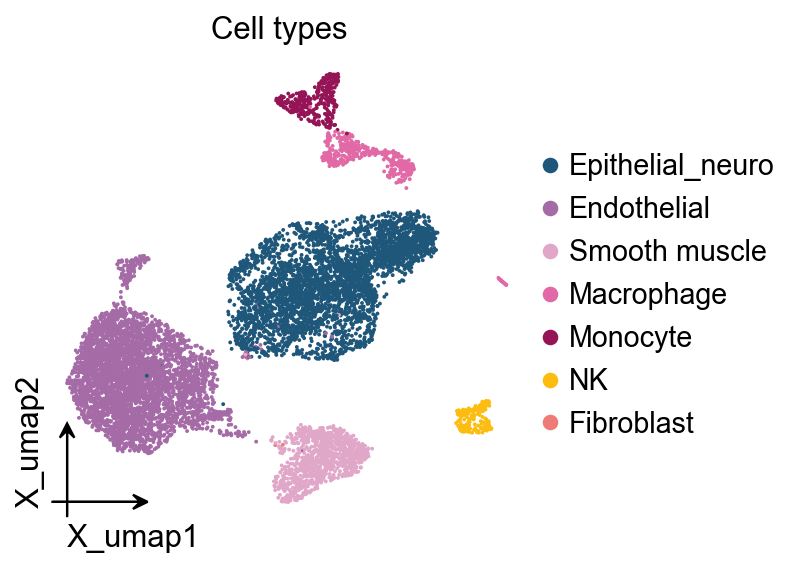

In [42]:
# UMAP coloured by cell-type labels
ov.pl.embedding(adata, basis="X_umap", color="labels_cl_unif2_broad",
                frameon="small", title="Cell types")

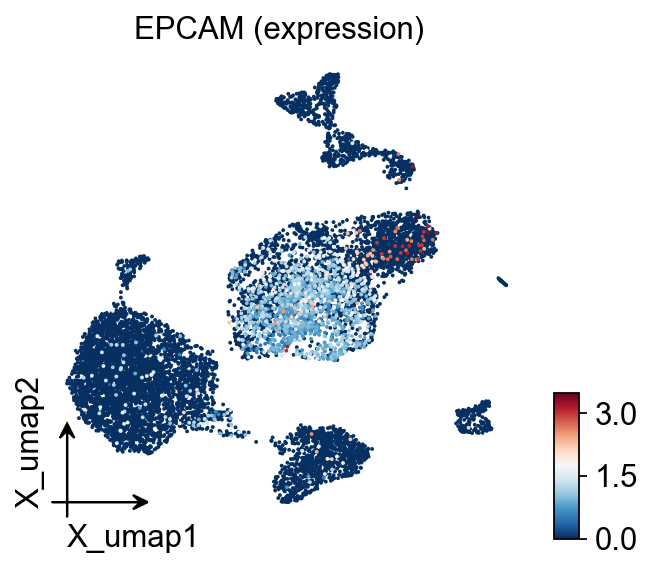

In [43]:
# UMAP coloured by a single gene — the expression vector is streamed from disk
ov.pl.embedding(adata, basis="X_umap", color=ensembl_id,
                frameon="small", title=f"{gene_symbol} (expression)")

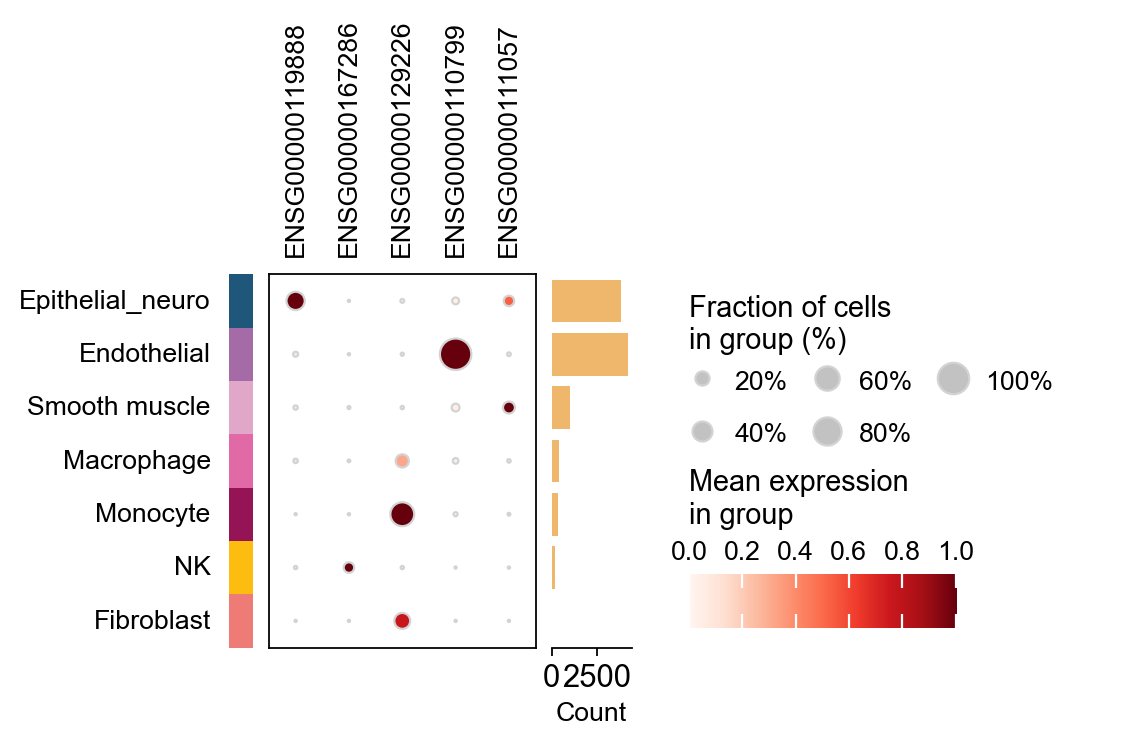

In [44]:
# Dotplot of several marker genes across cell types
markers = ["EPCAM", "CD3D", "CD19", "CD68", "VWF", "KRT18"]
marker_ids = [adata.var.index[adata.var["feature_name"] == g][0]
              for g in markers
              if (adata.var["feature_name"] == g).any()]

ov.pl.dotplot(adata, marker_ids, groupby="labels_cl_unif2_broad",
              standard_scale="var")

<Axes: xlabel='labels_cl_unif2_broad', ylabel='ENSG00000119888'>

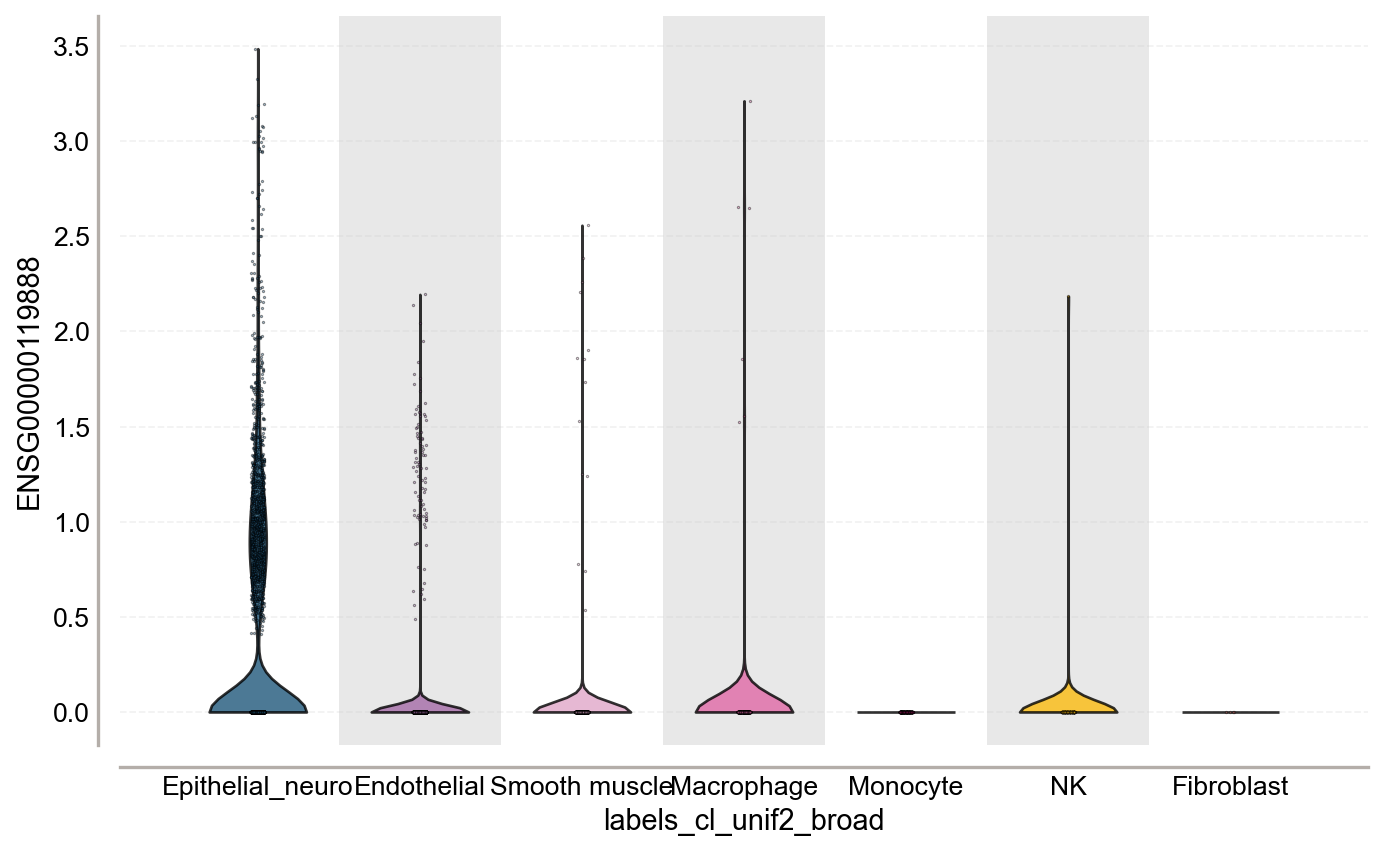

In [45]:
# Violin plot for one gene
ov.pl.violin(adata, keys=ensembl_id, groupby="labels_cl_unif2_broad")

## 12. Cleanup

`close()` releases the Rust file handle and any sidecar resources. It's idempotent and is called automatically by `__del__`, but explicit cleanup is good practice in long-running notebooks.

In [46]:
adata.close()